In [1]:
from res_opt_core import EnergyModel, Grid, AuctionMarket, plot_battery_operation
from hems_resopt.components.ev import EV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors

# Set default plot properties (rcParams)
plt.rcParams['figure.figsize'] = [15, 8]  # Set the default figure size (width, height)
plt.rcParams['figure.dpi'] = 300  # Set the resolution (300 DPI for high-quality output)
plt.rcParams['lines.linewidth'] = 1     # Set default line width
plt.rcParams['lines.color'] = 'b'         # Set default line color (blue in this case)
plt.rcParams['axes.grid'] = True 
plt.rcParams['axes.grid.axis'] = 'y'
plt.rcParams['grid.alpha'] = 0.3    
plt.rcParams['axes.titlecolor'] = '#616161'
plt.rcParams['axes.labelcolor'] = '#616161'
plt.rcParams['xtick.color'] = '#616161'
plt.rcParams['ytick.color'] = '#616161'
plt.rcParams['text.color'] = '#616161'
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.markerscale'] = 1
plt.rcParams['legend.framealpha'] = 0.5
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.bottom'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["#BCCF02", "#6C9C30", "#3E5C17", "#a7b805"]) 
# plt.rcParams["patch.facecolor"] = "#BCCF02"

plt.rcParams['figure.constrained_layout.use'] = True # alternativ zu tight_layout(). noch testen sonst deaktivieren

In [2]:
def build_input_dict(
    charger_ids: list[str],
    value: float | dict[str, float],
) -> dict[str, float]:
    """
    Build a per-charger input dictionary from either a scalar or an
    existing dict."""

    if isinstance(value, dict):
            return value                                    # already per-charger
    return {cid: value for cid in charger_ids}         # broadcast scalar → dict

In [3]:
# from pyspark.sql import SparkSession

# # Create a Spark Session with Databricks
# spark = SparkSession.builder.getOrCreate()

# # ── Time Index ─────────────────────────────────────────────────────────────────
# start_time = pd.Timestamp('2025-01-01')
# end_time   = pd.Timestamp('2025-01-31')
# idx        = pd.date_range(start=start_time, freq='15min', end=end_time)

# # Pre-format timestamps as SQL-safe strings once — reuse everywhere
# start_str = start_time.strftime('%Y-%m-%d %H:%M:%S')   # '2026-01-01 00:00:00'
# end_str   = end_time.strftime('%Y-%m-%d %H:%M:%S')     # '2026-04-01 00:00:00'

# charger_ids     = ['ECTX6MQM', 'EC93FYLG', 'ECR5S7HB', 'EC4BSFH6']
# charger_ids_sql = ", ".join(f"'{cid}'" for cid in charger_ids)

# # ── Load raw data from Databricks ─────────────────────────────────────────────
# sql_raw = f"""
#     SELECT
#         carConnected,
#         carDisconnected,
#         kiloWattHours,
#         chargerId,
#         SiteName
#     FROM ckw_gbed_dev.flex_bronze.tbl_easee_sessions
#     WHERE chargerId    IN ({charger_ids_sql})
#       AND carConnected >  '{start_str}'
# """

# df  = spark.sql(sql_raw)
# pdf = df.toPandas()     # bring subset to local memory

# # ── Query 2 — Dynamic Tariffs ──────────────────────────────────────────────────
# sql_dyn_tariff = f"""
#     SELECT start_timestamp_UTC, CHF_per_kWh
#     FROM ckw_gbed_dev.flex_silver.tbl_dynamic_tariffs
#     WHERE tariff_name           =  'CKW_grid_home_Rp_per_kWh'
#       AND start_timestamp_UTC  >= TIMESTAMP('{start_str}')
#       AND start_timestamp_UTC  <= TIMESTAMP('{end_str}')
# """

# df_2 = spark.sql(sql_dyn_tariff)
# df_dyn_tarif = df_2.toPandas()


In [4]:
from res_opt_core import EnergyModel, Grid, AuctionMarket, plot_battery_operation
from hems_resopt.components.ev import EV
import numpy as np
import pandas as pd

# ── Session Data ──────────────────────────────────────────────────────────────
easee_sessions = pd.read_parquet(r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\data\01_raw\filtered_easee_sessions.parquet')
site_data = pd.read_parquet(r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\data\01_raw\filtered_easee_sites.parquet')
easee_sessions['carConnected']    = pd.to_datetime(easee_sessions['carConnected'], utc=True)
easee_sessions['carDisconnected'] = pd.to_datetime(easee_sessions['carDisconnected'], utc=True)

# ── Sessions per site ID with min/max carConnected ────────────────────────────
sessions_per_site = (
    easee_sessions
    .groupby('site_id')
    .agg(
        session_count = ('site_id',      'size'),
        first_session = ('carConnected', 'min'),
        last_session  = ('carConnected', 'max'),
    )
    .reset_index()
    .sort_values('session_count', ascending=False)
)

sessions_per_site = sessions_per_site.merge(
    site_data[['id']].drop_duplicates(),
    left_on='site_id', right_on='id',
    how='left'
).drop(columns='id')

print(sessions_per_site[['site_id', 'session_count', 'first_session', 'last_session']].to_string(index=False))

pdf = easee_sessions[easee_sessions['site_id'] == 275947]

# ── Price Data ──────────────────────────────────────────────────────────────
df_dyn_tarif = pd.read_csv(r'C:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\data\01_raw\ckw_dyn_tarif_26.csv')
df_dyn_tarif['Timestamp'] = pd.to_datetime(df_dyn_tarif['Timestamp'], dayfirst=True, errors='coerce')
df_dyn_tarif['Timestamp'] = df_dyn_tarif['Timestamp'].dt.tz_localize('UTC')
df_dyn_tarif = df_dyn_tarif.set_index('Timestamp', drop=True).sort_index()

# ── Time Index ─────────────────────────────────────────────────────────────────
start_time = pd.Timestamp('2026-01-01', tz='UTC')
end_time   = pd.Timestamp('2026-05-01', tz='UTC')
idx        = pd.date_range(start=start_time, freq='15min', end=end_time, tz='UTC')

# ── Optimization Dataframe -────────────────────────────────────────────────────
columns      = ['power_min', 'power_max', 'e_in', 'e_out', 'e_cap']
df_ev_inputs = pd.DataFrame(index=idx, columns=columns, dtype=float)
df_ev_inputs.index = pd.to_datetime(df_ev_inputs.index, format='mixed', dayfirst=True)

# ── Assign to df_ev_inputs ─────────────────────────────────────────────────────
df_ev_inputs['dyn_tarif'] = df_dyn_tarif['home dynamic']

 site_id  session_count             first_session              last_session
  300051           2393 2024-12-31 16:34:08+00:00 2026-04-29 12:56:43+00:00
  275947           1603 2024-12-30 15:13:26+00:00 2026-04-29 20:00:11+00:00
  287032            920 2024-12-31 18:11:07+00:00 2026-04-28 16:13:59+00:00
  405891            900 2024-12-31 22:07:17+00:00 2026-04-29 17:21:52+00:00
  408561            371 2025-01-03 08:12:01+00:00 2026-04-25 21:59:36+00:00
  419588            329 2024-12-31 12:50:05+00:00 2026-04-28 19:18:06+00:00
  328456            251 2025-01-02 09:38:44+00:00 2026-04-29 15:53:58+00:00
  587263            212 2025-01-05 13:40:54+00:00 2026-04-25 12:41:51+00:00
  263264            192 2025-01-01 10:30:08+00:00 2026-04-27 15:33:03+00:00
  226605            184 2025-01-01 14:58:42+00:00 2026-04-27 17:00:12+00:00
  585442            126 2025-01-06 19:22:12+00:00 2026-04-24 15:34:37+00:00
  667659             53 2025-10-14 16:43:56+00:00 2026-04-29 16:56:20+00:00


In [5]:
from hems_resopt.utils.pre_process_ev import prepare_sessions, build_connection_df, get_power_bounds, get_e_in_out_capacity
battery_sizes = 80
power_max_per_charger = 11


# ── Assemble df_ev_inputs ──────────────────────────────────────────────────────
columns      = ['power_min', 'power_max', 'e_in', 'e_out', 'energy_capacity']
# df_ev_inputs = pd.DataFrame(index=idx, columns=columns, dtype=float)

# Step 1 — prepare sessions
sessions = prepare_sessions(pdf, start_time, end_time)
# sessions = sessions.drop(columns=['Unnamed: 0'])
sessions = sessions.drop_duplicates()

# give same inputs to every charger -> alterantively a manual dict can be build with indiviudal values per chargerId
charger_ids = sessions['chargerId'].unique().tolist()   # or pass your explicit list

battery_dict = build_input_dict(charger_ids, battery_sizes)
power_dict   = build_input_dict(charger_ids, power_max_per_charger)

# Step 2 — build the central connection matrix
connection_df = build_connection_df(sessions, idx, charger_ids)

# Step 3 — fill each input via its dedicated function
df_ev_inputs[['power_min', 'power_max']] = get_power_bounds(connection_df, power_dict)
df_ev_inputs[['e_in', 'e_out', 'e_cap']], capped_kWh_list = get_e_in_out_capacity(sessions, connection_df, idx, battery_dict, power_dict)


INFO: Total kWh removed by power feasibility cap: 145.24 kWh across 31 sessions.


In [6]:
# Model setup
model = EnergyModel(
    num_steps=len(df_ev_inputs.index),
    slot_length="15min",
    solver="scip",
)

# Components
ev_fleet = EV(
    name="EV_Fleet",
    power_nominal=200, # How to handle power nominal -> max of all connected powers?
    power_min=df_ev_inputs['power_min'],
    power_max=df_ev_inputs['power_max'],
    energy_capacity=df_ev_inputs['e_cap'],
    soc_initial=0.0,
    soc_final=None,
    energy_in_slot_start=df_ev_inputs['e_in'],
    energy_out_slot_end=df_ev_inputs['e_out']
)



dynamischer_tariff = AuctionMarket(
    name='dynamic_tariff',
    price_curve=df_ev_inputs['dyn_tarif'],
    #market_time_unit='1hr' definier resolutoin of market 
)

grid = Grid(
    name="grid",
    assets=[ev_fleet],
    markets=[dynamischer_tariff],
    
    # power_min=-2.0, #kW -> bezug aus netz
)

model.add_component(ev_fleet)
model.add_component(dynamischer_tariff)
model.add_component(grid)

model.build_and_run(silent=False) #scip outputs visible

df_results = model.results.timeseries_to_pandas()

SCIP version 10.0.2 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 8.0.2] [GitHash: b8eaf989f9]
Copyright (c) 2002-2026 Zuse Institute Berlin (ZIB)

External libraries: 
  SoPlex 8.0.2         Linear programming solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: cfadddc4]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (github.com/coin-or/CppAD)
  ZLIB 1.3.2           General purpose compression library by J. Gailly and M. Adler (zlib.net)
  MPFR 4.2.2           GNU Multiple Precision Floating-Point Reliable Library (mpfr.org)
  Boost 1.88.0         Boost C++ Libraries (boost.org)
  TinyCThread 1.2      small portable implementation of the C11 threads API (tinycthread.github.io)
  GMP 6.3.0            GNU Multiple Precision Arithmetic Library developed by T. Granlund (gmplib.org)
  ZIMPL 3.7.1          Zuse Institute Mathematical Programming Language developed by T. Koch (zimpl.zib.de)
  AMPL/MP 4.0.4 


                       EV CHARGING OPTIMISATION — SUMMARY                       

-- Energy --
  Total Energy Charged [kWh]                                     9,639.17 kWh
  Energy in Raw Sessions [kWh]                                   9,238.64 kWh
  Energy Lost to Power Cap [kWh]                                   145.24 kWh
  Energy Lost to Power Cap [%]                                          1.57%

-- Costs (optimized vs flat) --
  Energy Costs Grid Opt [CHF]                                      195.66 CHF
  Energy Costs ELV Opt [CHF]                                        1,928 CHF
  Peak Costs Opt [CHF]                                              2,090 CHF
  Total Optimized Costs [CHF]                                       4,213 CHF
  Energy Costs Grid (flat tariff) [CHF]                            606.81 CHF
  Energy Costs ELV (flat tariff) [CHF]                              1,928 CHF
  Peak costs (flat tariff) [CHF]                                    2,090 CHF
  Total costs

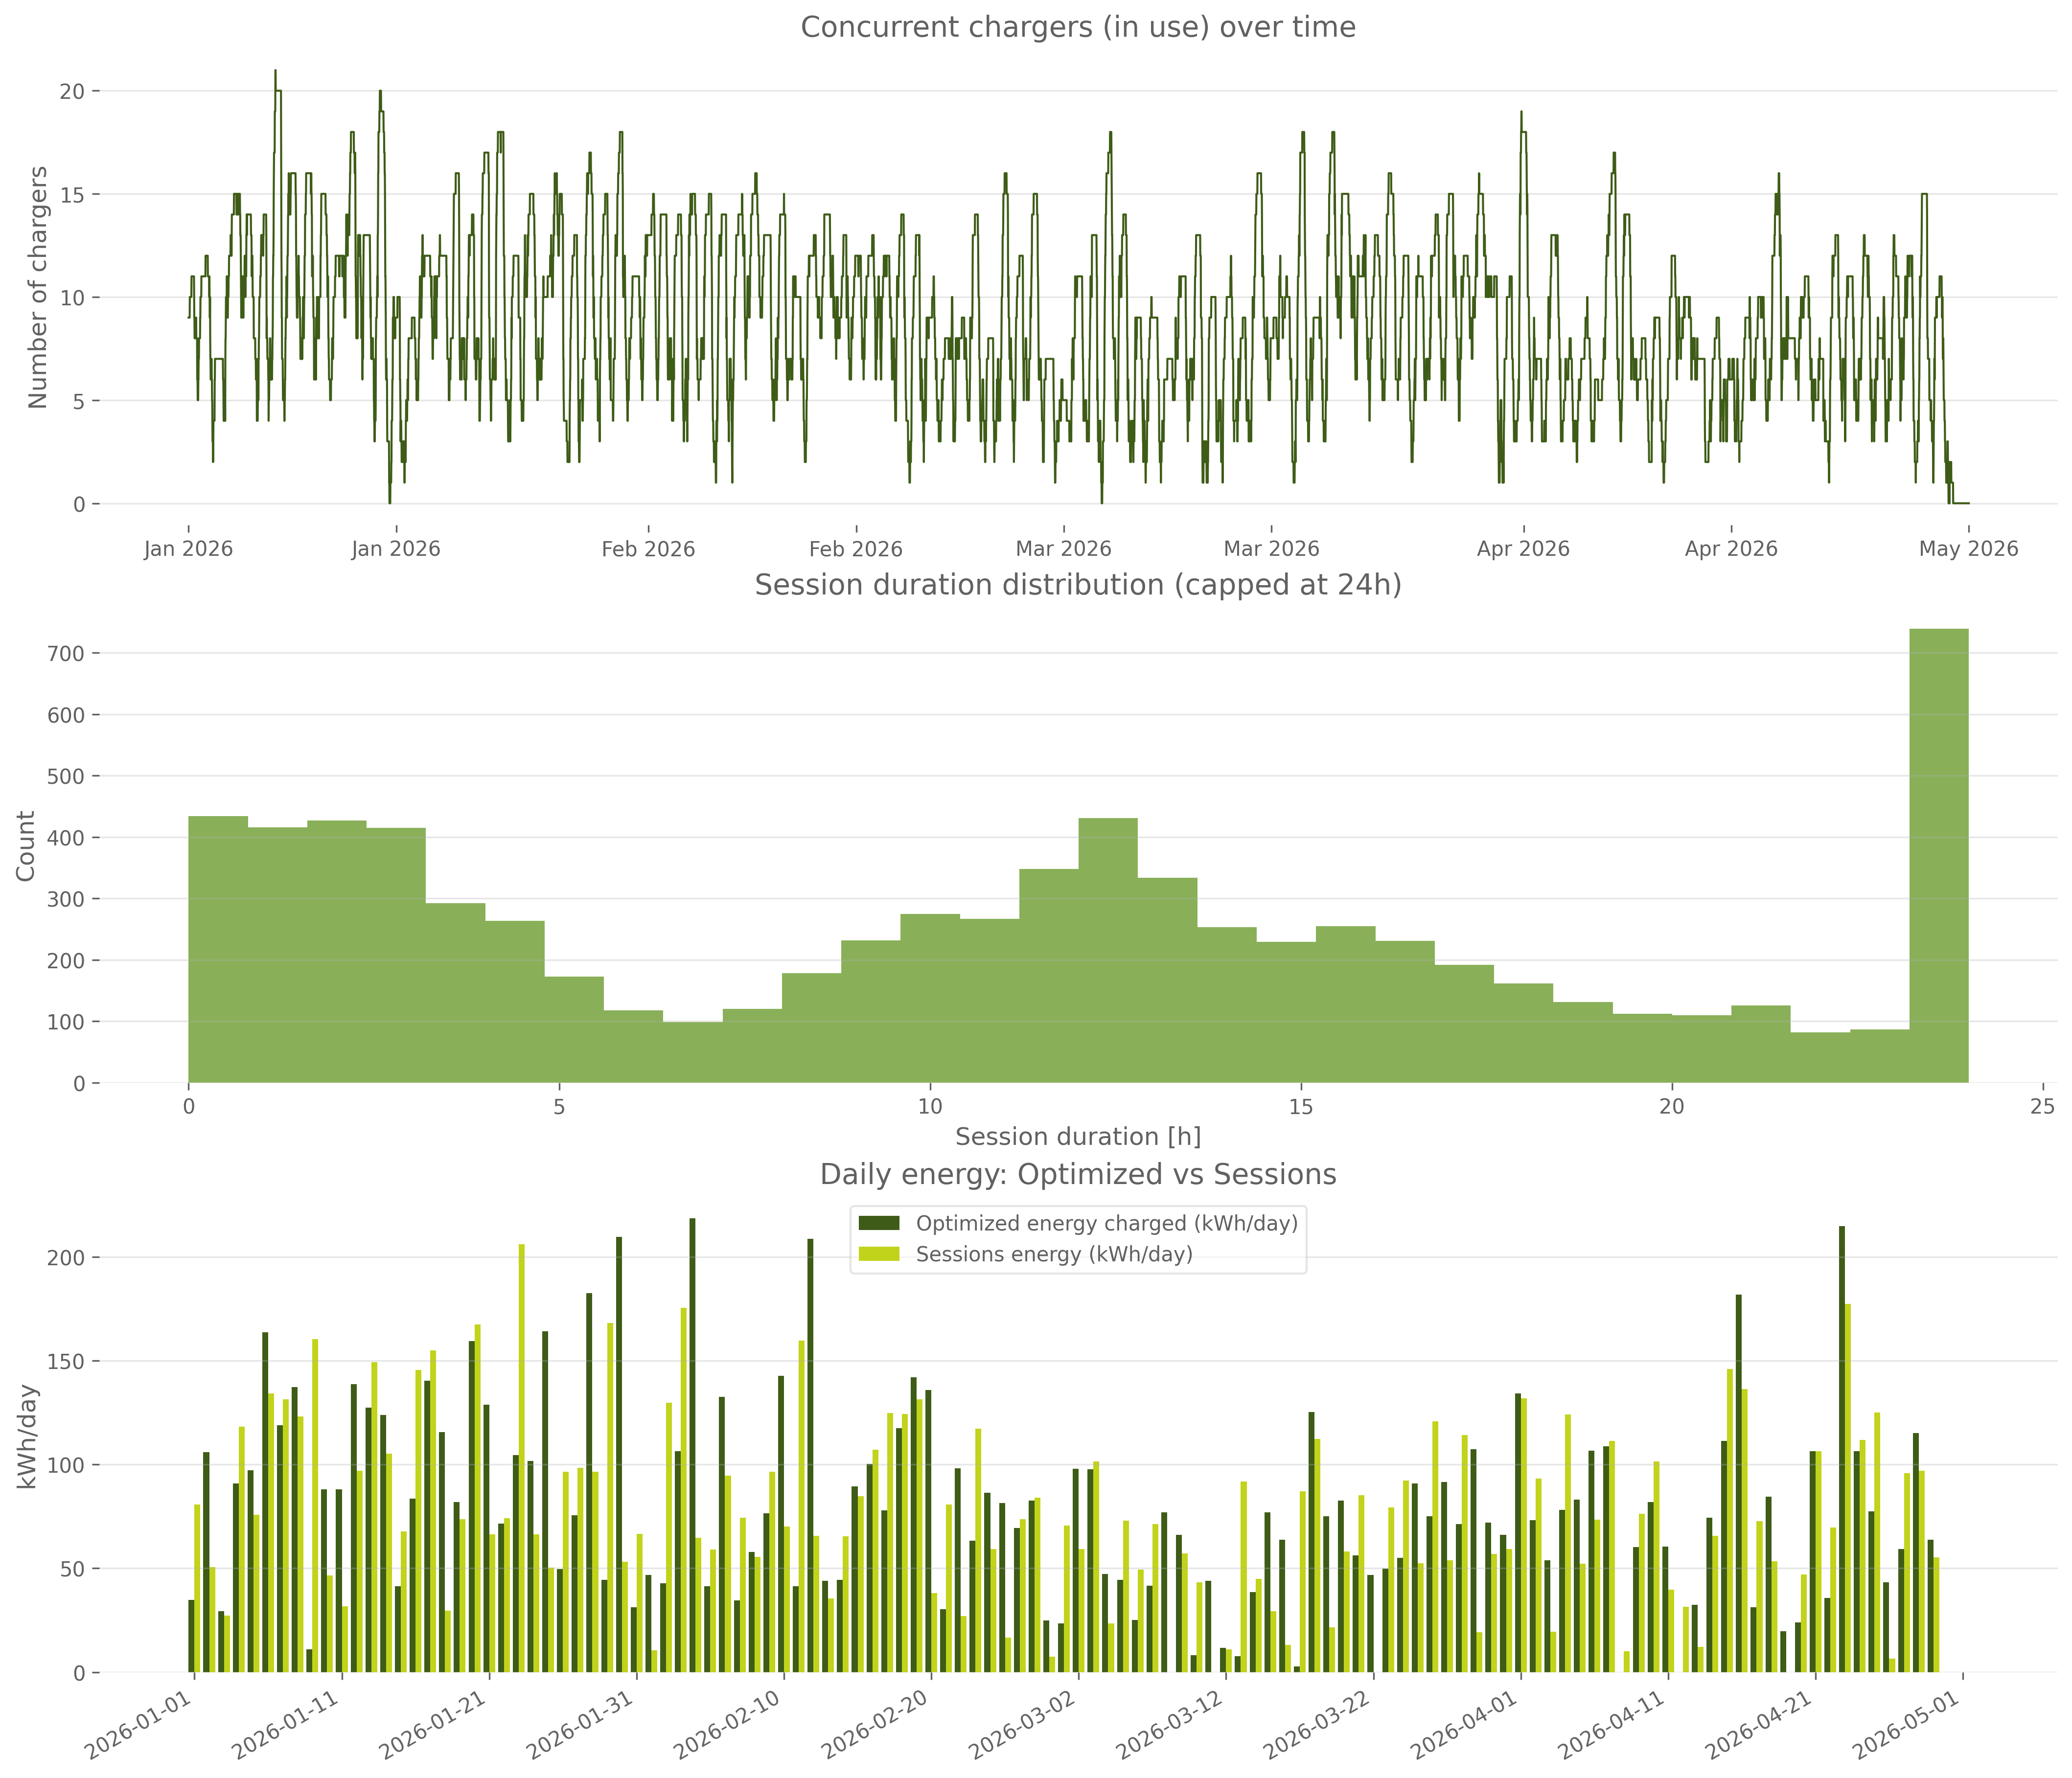

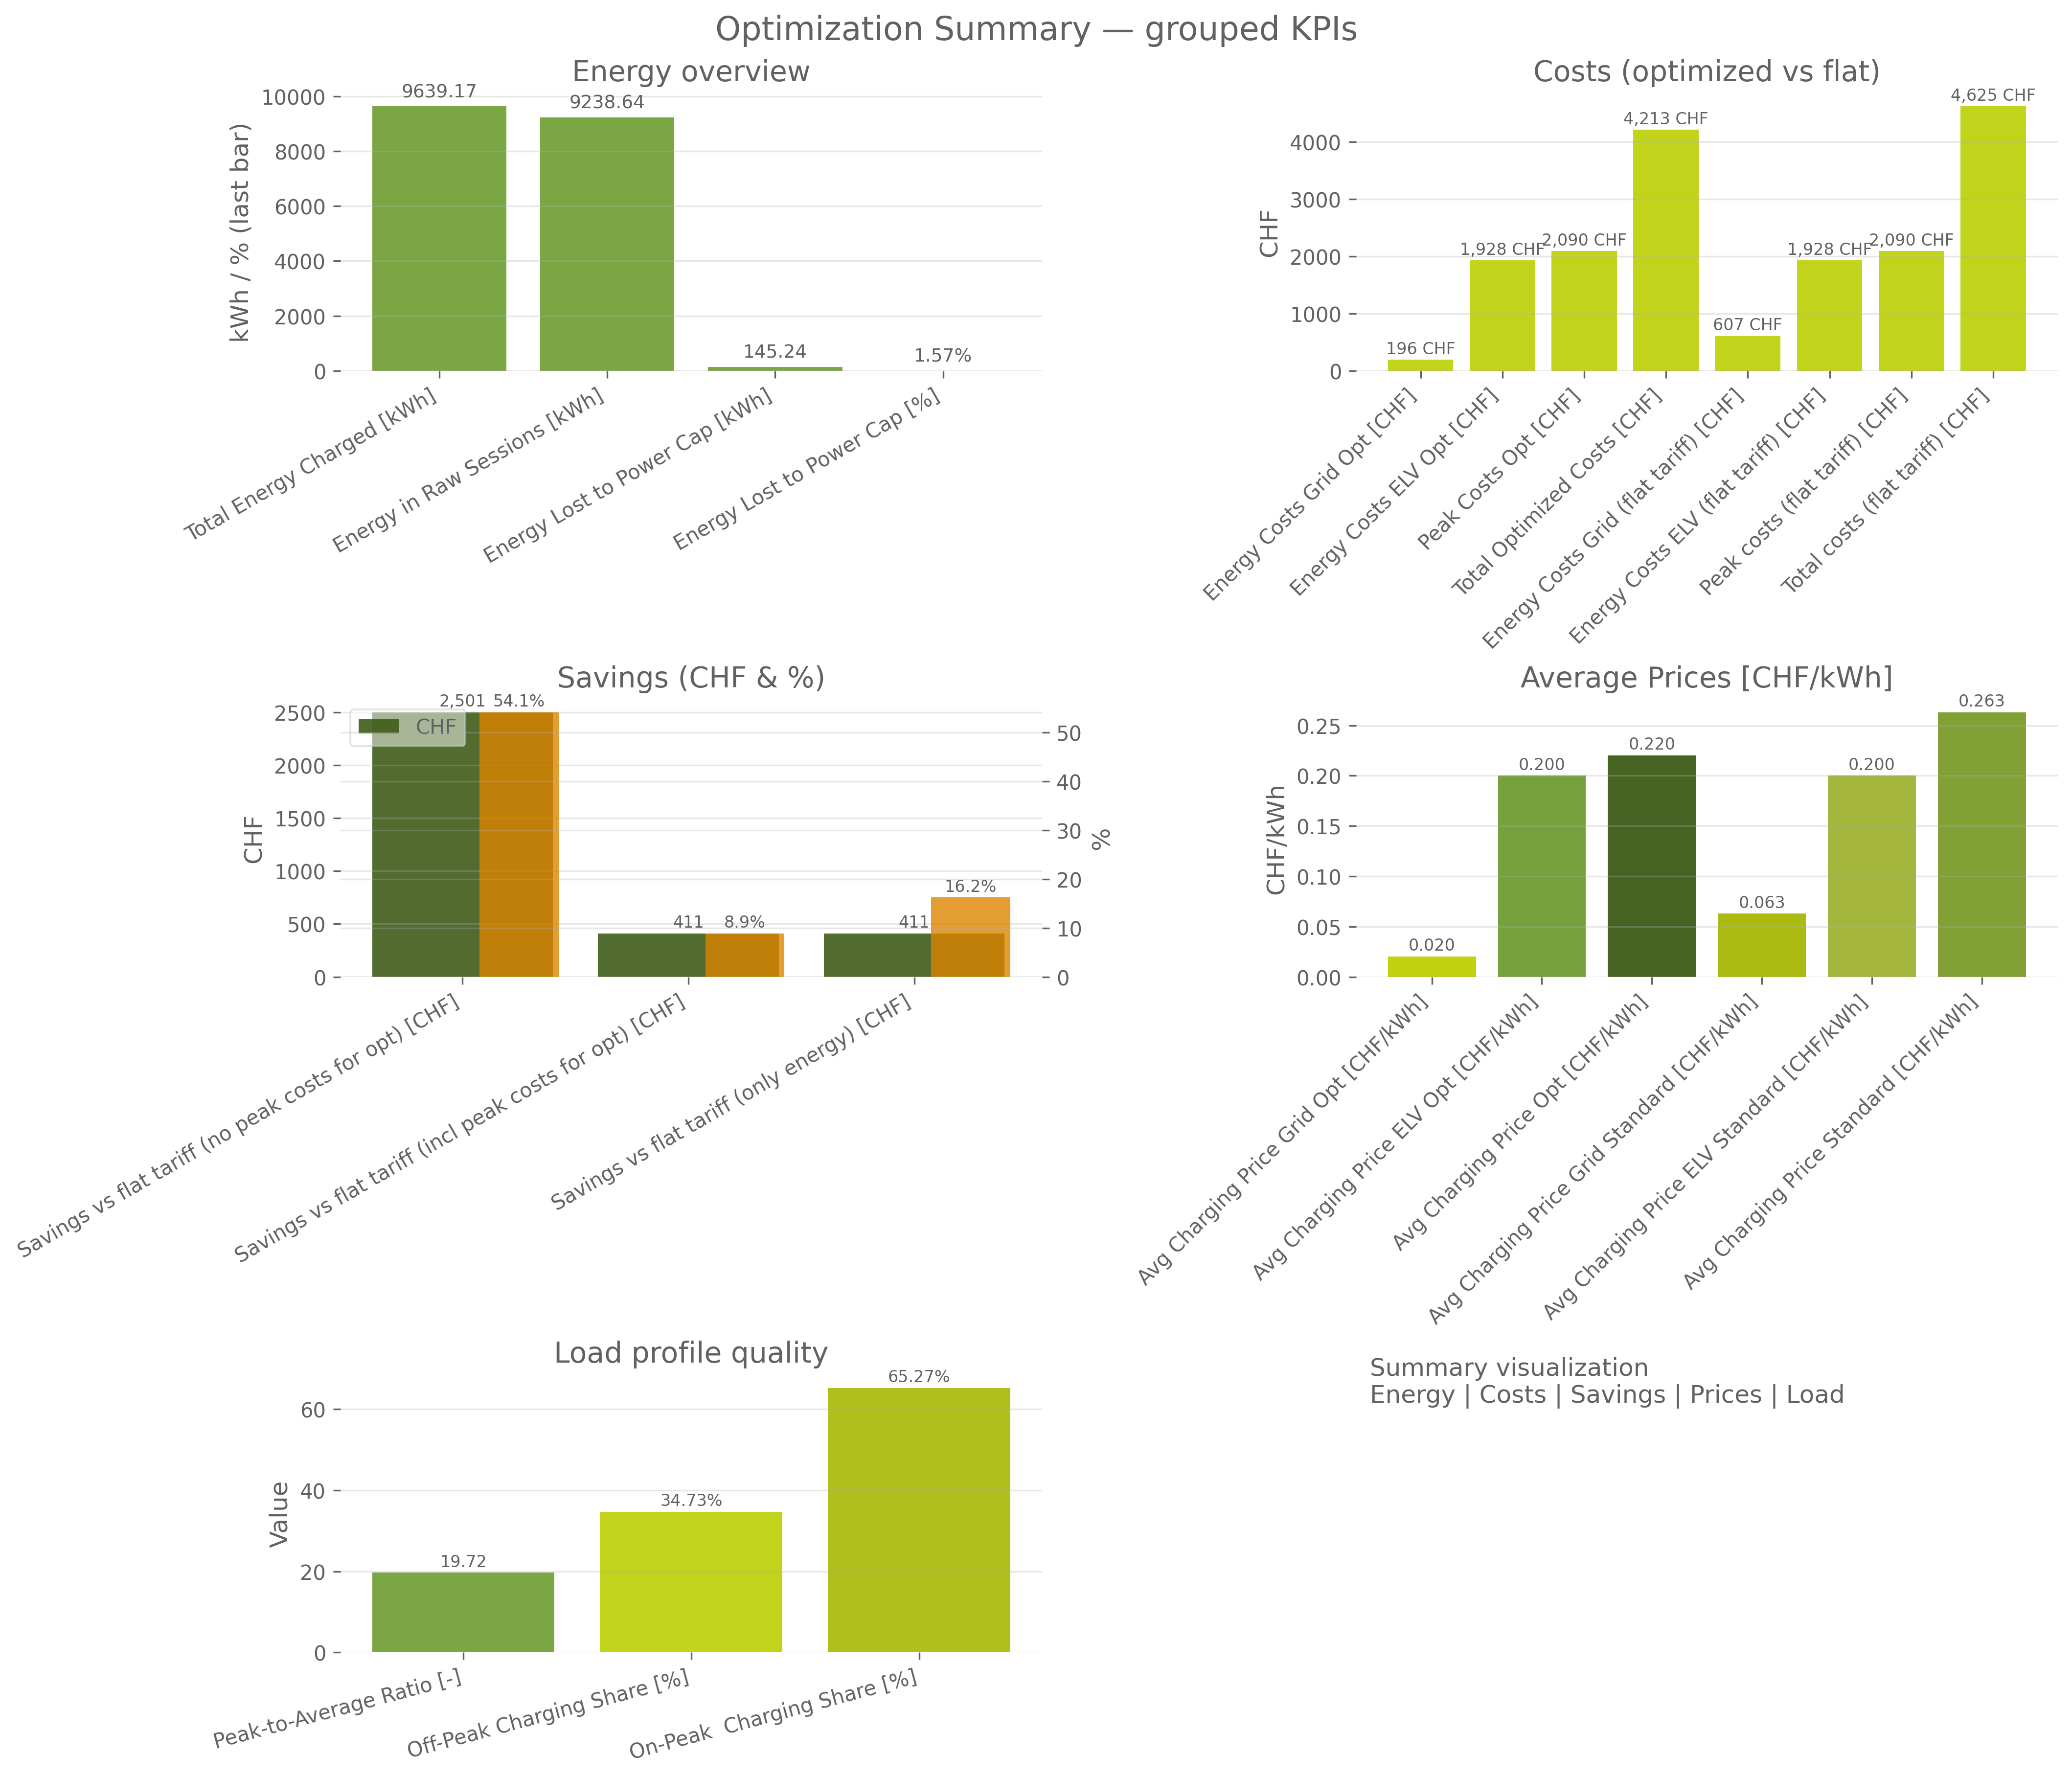

c:\Users\ckw-ThCa\OneDrive - CKW-Gruppe\Origination-General\Team\Caspar\Model_HEMS\hems_resopt\hems_resopt\utils\post_process_ev.py:303: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


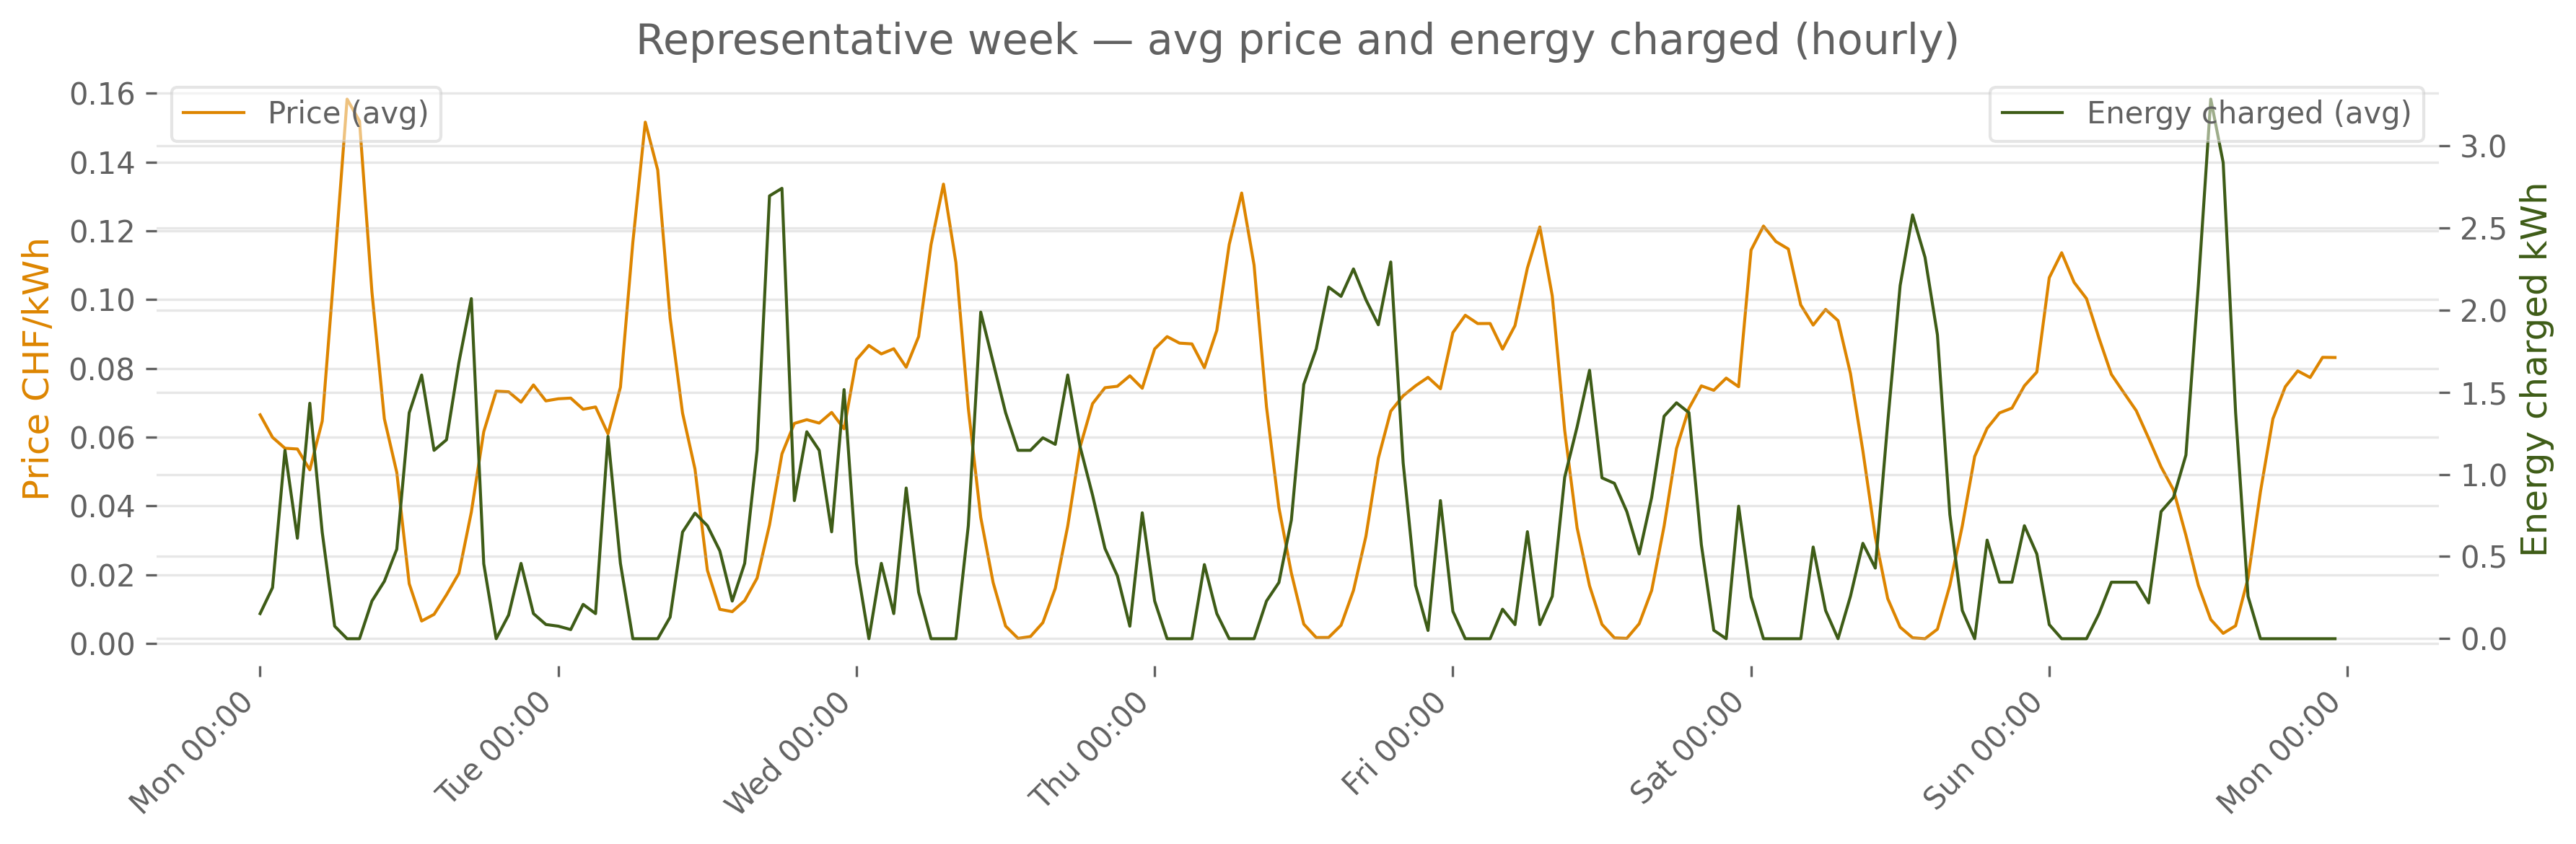

In [8]:
from hems_resopt.utils.post_process_ev import plot_charger_usage, plot_representative_week, plot_summary_bars, compute_ev_optimization_summary, print_summary

df_post_process, summary_dict, monthly_df = compute_ev_optimization_summary(
    df_results=df_results,
    df_ev_inputs=df_ev_inputs,
    idx=idx,
    sessions=sessions,
    capped_kWh_list=capped_kWh_list,
    peak_power_price=10.0,
    energy_costs=0.2
)
print_summary(summary_dict)

# C: chargers used
plot_charger_usage(easee_sessions, df_post_process, idx, sessions)
plot_summary_bars(summary_dict)
# representative week
plot_representative_week(df_ev_inputs['dyn_tarif'], df_post_process['energy_charged'])


In [9]:
# Plot the State of SoC of pool over time to understand the optimization
df_results['EV_Fleet__var_soc_slot_start']
df_results['EV_Fleet__var_soc_slot_end']
# plot_battery_operation(df_results.index, ev_fleet, {"dynamischer_tariff": df_ev_inputs['dyn_tarif']})

timestamp
2000-01-01 00:00:00   -0.0
2000-01-01 00:15:00    0.0
2000-01-01 00:30:00    0.0
2000-01-01 00:45:00    0.0
2000-01-01 01:00:00    0.0
                      ... 
2000-04-29 23:00:00    0.0
2000-04-29 23:15:00    0.0
2000-04-29 23:30:00    0.0
2000-04-29 23:45:00    0.0
2000-04-30 00:00:00    0.0
Name: EV_Fleet__var_soc_slot_end, Length: 11521, dtype: float64